# Entraînement Deep Learning — prédiction des compétences IA

Ce notebook entraîne un modèle **CamemBERT** pour prédire plusieurs compétences IA à partir des informations d'une formation.

La tâche est une **classification multi-étiquette** : une formation peut correspondre à plusieurs compétences simultanément.

Points importants :

- le jeu contient peu de données, donc on affine un modèle préentraîné au lieu d'entraîner un réseau depuis zéro ;
- les doublons sont séparés par intitulé de formation pour éviter les fuites de données ;
- les métriques principales sont le F1 micro et le F1 macro ;
- le seuil de décision est ajusté sur le jeu de validation.


In [1]:
# À exécuter une seule fois dans l'environnement Python du notebook
%pip install -U pandas numpy scikit-learn torch transformers datasets accelerate sentencepiece matplotlib


Note: you may need to restart the kernel to use updated packages.


In [2]:
from pathlib import Path
import re
import json
import unicodedata
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import (
    f1_score,
    precision_score,
    recall_score,
    classification_report,
)

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
)

print("PyTorch :", torch.__version__)
print("CUDA disponible :", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU :", torch.cuda.get_device_name(0))


/home/bibi/deepforma/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch : 2.12.1+cu130
CUDA disponible : True
GPU : NVIDIA GeForce RTX 5060


## 1. Chargement du jeu de données

Place le fichier CSV dans le même dossier que ce notebook, ou modifie `CSV_PATH`.


In [3]:
CSV_PATH = Path("Dataset_V7_Anton_CSV - Dataset_V7_Anton_CSV.csv.csv")

if not CSV_PATH.exists():
    raise FileNotFoundError(
        f"Fichier introuvable : {CSV_PATH.resolve()}\n"
        "Modifie CSV_PATH avec le chemin réel du fichier."
    )

df = pd.read_csv(CSV_PATH)

print("Dimensions :", df.shape)
display(df.head(3))
print("\nColonnes :")
for col in df.columns:
    print("-", col)


Dimensions : (387, 15)


,#,Organisme de formation,Intitulé de la formation,Type de certification,Code certification,Niveau,Codes ROME,Compétences IA extraites,Modalité,Durée,Prix TTC (€),Public cible,Tags TrendRadar,✅ Relu / Validé (oui/non),🗒 Corrections / Remarques
0,1,LEARN TO ACT,BTS Communication,RNCP,37198,"BAC+2 : DEUG, BT, DUT... (NIVEAU 5)",E1103,| Prompt Engineering | IA Générative | Éthiqu...,distance,2 ans,450.0,Apprenants Bac+2 intégrant l'IA dans un cursus...,machine-learning | prompt-engineering | ia-gen...,x,NaN
1,2,LEARN TO ACT,BTS Communication,RNCP,37198,"BAC+2 : DEUG, BT, DUT... (NIVEAU 5)",E1103,Prompt Engineering | IA Générative | No-code /...,distance,2 ans,1300.0,Apprenants Bac+2 intégrant l'IA dans un cursus...,prompt-engineering | ia-generative | no-code |...,x,NaN
2,3,EXPERTAIDE,Améliorer l'efficacité de sa TPE à l'aide de l'IA,RS,7311,0,0,Automatisation,distance,35h,1650.0,Dirigeants de TPE/PME souhaitant intégrer l'IA...,prompt-engineering | ethique-ia | automatisati...,x,NaN



Colonnes :
- #
- Organisme de formation
- Intitulé de la formation
- Type de certification
- Code certification
- Niveau
- Codes ROME
- Compétences IA extraites
- Modalité
- Durée
- Prix TTC (€)
- Public cible
- Tags TrendRadar
- ✅ Relu / Validé (oui/non)
- 🗒 Corrections / Remarques


## 2. Nettoyage et construction du texte d'entrée

La cible est la colonne `Compétences IA extraites`.

Le modèle utilisera :

- l'intitulé ;
- le type de certification ;
- le niveau ;
- les codes ROME ;
- la modalité ;
- la durée ;
- le public cible.

Les tags TrendRadar ne sont volontairement pas utilisés comme entrée, car ils contiennent souvent directement la réponse attendue.


In [4]:
TARGET_COLUMN = "Compétences IA extraites"

INPUT_COLUMNS = [
    "Intitulé de la formation",
    "Type de certification",
    "Niveau",
    "Codes ROME",
    "Modalité",
    "Durée",
    "Public cible",
]

def normalize_text(value):
    if pd.isna(value):
        return ""
    value = str(value).strip()
    value = re.sub(r"\s+", " ", value)
    return value

def normalize_group_title(value):
    value = normalize_text(value).lower()
    value = unicodedata.normalize("NFKD", value)
    value = "".join(c for c in value if not unicodedata.combining(c))
    value = re.sub(r"[^a-z0-9]+", " ", value)
    return re.sub(r"\s+", " ", value).strip()

def parse_labels(value):
    if pd.isna(value):
        return []
    labels = []
    for item in str(value).split("|"):
        item = item.strip()
        if item:
            labels.append(item)
    return sorted(set(labels))

def build_input_text(row):
    parts = []
    for column in INPUT_COLUMNS:
        value = normalize_text(row.get(column, ""))
        if value and value != "0":
            parts.append(f"{column} : {value}")
    return " [SEP] ".join(parts)

data = df.copy()
data["labels_text"] = data[TARGET_COLUMN].apply(parse_labels)
data["text"] = data.apply(build_input_text, axis=1)
data["group_title"] = data["Intitulé de la formation"].apply(normalize_group_title)

data = data[data["labels_text"].map(len) > 0].reset_index(drop=True)

print("Nombre de lignes utilisables :", len(data))
print("Nombre d'intitulés uniques :", data["group_title"].nunique())
print("Exemple de texte :\n")
print(data.loc[0, "text"])
print("\nCompétences :", data.loc[0, "labels_text"])


Nombre de lignes utilisables : 386
Nombre d'intitulés uniques : 66
Exemple de texte :

Intitulé de la formation : BTS Communication [SEP] Type de certification : RNCP [SEP] Niveau : BAC+2 : DEUG, BT, DUT... (NIVEAU 5) [SEP] Codes ROME : E1103 [SEP] Modalité : distance [SEP] Durée : 2 ans [SEP] Public cible : Apprenants Bac+2 intégrant l'IA dans un cursus BTS/DUT

Compétences : ['IA Générative', 'No-code / Low-code', 'Prompt Engineering', 'Éthique IA & RGPD']


## 3. Analyse des étiquettes

Nombre de compétences distinctes : 20


,occurrences
labels_text,
Éthique IA & RGPD,279
IA Générative,248
Prompt Engineering,201
Automatisation,176
NLP / Traitement du langage,162
Machine Learning,97
Data Science,96
Visualisation,95
LangChain / Agents RAG,90


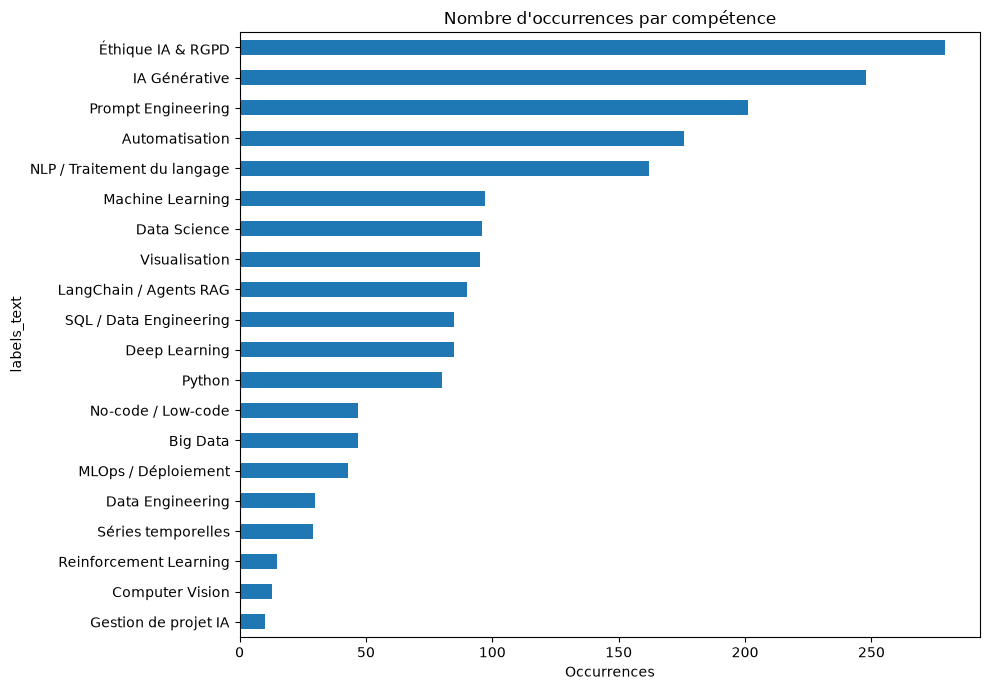

In [5]:
label_counts = (
    data["labels_text"]
    .explode()
    .value_counts()
    .sort_values(ascending=True)
)

print("Nombre de compétences distinctes :", len(label_counts))
display(label_counts.sort_values(ascending=False).to_frame("occurrences"))

plt.figure(figsize=(10, 7))
label_counts.plot(kind="barh")
plt.title("Nombre d'occurrences par compétence")
plt.xlabel("Occurrences")
plt.tight_layout()
plt.show()


## 4. Découpage sans fuite de données

Les lignes ayant le même intitulé normalisé restent dans le même sous-ensemble.

Répartition visée :

- 70 % entraînement ;
- 15 % validation ;
- 15 % test.


In [6]:
RANDOM_STATE = 42

groups = data["group_title"]

first_split = GroupShuffleSplit(
    n_splits=1,
    train_size=0.70,
    random_state=RANDOM_STATE,
)

train_idx, temp_idx = next(
    first_split.split(data, groups=groups)
)

train_df = data.iloc[train_idx].reset_index(drop=True)
temp_df = data.iloc[temp_idx].reset_index(drop=True)

second_split = GroupShuffleSplit(
    n_splits=1,
    train_size=0.50,
    random_state=RANDOM_STATE,
)

val_idx, test_idx = next(
    second_split.split(temp_df, groups=temp_df["group_title"])
)

val_df = temp_df.iloc[val_idx].reset_index(drop=True)
test_df = temp_df.iloc[test_idx].reset_index(drop=True)

print("Train :", len(train_df), "lignes,", train_df["group_title"].nunique(), "groupes")
print("Validation :", len(val_df), "lignes,", val_df["group_title"].nunique(), "groupes")
print("Test :", len(test_df), "lignes,", test_df["group_title"].nunique(), "groupes")

assert set(train_df["group_title"]).isdisjoint(set(val_df["group_title"]))
assert set(train_df["group_title"]).isdisjoint(set(test_df["group_title"]))
assert set(val_df["group_title"]).isdisjoint(set(test_df["group_title"]))

print("Aucune fuite de groupe détectée.")


Train : 198 lignes, 46 groupes
Validation : 131 lignes, 10 groupes
Test : 57 lignes, 10 groupes
Aucune fuite de groupe détectée.


## 5. Encodage multi-étiquette

In [7]:
mlb = MultiLabelBinarizer()
mlb.fit(data["labels_text"])

LABEL_NAMES = list(mlb.classes_)
NUM_LABELS = len(LABEL_NAMES)

def add_binary_labels(frame):
    frame = frame.copy()
    encoded = mlb.transform(frame["labels_text"])
    frame["labels"] = [row.astype(np.float32).tolist() for row in encoded]
    return frame

train_df = add_binary_labels(train_df)
val_df = add_binary_labels(val_df)
test_df = add_binary_labels(test_df)

id2label = {i: label for i, label in enumerate(LABEL_NAMES)}
label2id = {label: i for i, label in id2label.items()}

print("Nombre de classes :", NUM_LABELS)
print(LABEL_NAMES)


Nombre de classes : 20
['Automatisation', 'Big Data', 'Computer Vision', 'Data Engineering', 'Data Science', 'Deep Learning', 'Gestion de projet IA', 'IA Générative', 'LangChain / Agents RAG', 'MLOps / Déploiement', 'Machine Learning', 'NLP / Traitement du langage', 'No-code / Low-code', 'Prompt Engineering', 'Python', 'Reinforcement Learning', 'SQL / Data Engineering', 'Séries temporelles', 'Visualisation', 'Éthique IA & RGPD']


## 6. Tokenisation avec CamemBERT

In [8]:
MODEL_NAME = "camembert-base"
MAX_LENGTH = 256

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def to_hf_dataset(frame):
    return Dataset.from_pandas(
        frame[["text", "labels"]],
        preserve_index=False,
    )

train_ds = to_hf_dataset(train_df)
val_ds = to_hf_dataset(val_df)
test_ds = to_hf_dataset(test_df)

def tokenize_batch(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        padding="max_length",
        max_length=MAX_LENGTH,
    )

train_ds = train_ds.map(tokenize_batch, batched=True)
val_ds = val_ds.map(tokenize_batch, batched=True)
test_ds = test_ds.map(tokenize_batch, batched=True)

columns = ["input_ids", "attention_mask", "labels"]
train_ds.set_format(type="torch", columns=columns)
val_ds.set_format(type="torch", columns=columns)
test_ds.set_format(type="torch", columns=columns)

train_ds


Map: 100%|██████████| 57/57 [00:00<00:00, 10228.26 examples/s]


Dataset({
    features: ['text', 'labels', 'input_ids', 'attention_mask'],
    num_rows: 198
})

## 7. Création et entraînement du modèle

In [9]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    id2label=id2label,
    label2id=label2id,
    problem_type="multi_label_classification",
)

def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))

DECISION_THRESHOLD = 0.50

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    probabilities = sigmoid(logits)
    predictions = (probabilities >= DECISION_THRESHOLD).astype(int)

    return {
        "f1_micro": f1_score(labels, predictions, average="micro", zero_division=0),
        "f1_macro": f1_score(labels, predictions, average="macro", zero_division=0),
        "precision_micro": precision_score(labels, predictions, average="micro", zero_division=0),
        "recall_micro": recall_score(labels, predictions, average="micro", zero_division=0),
    }

training_args = TrainingArguments(
    output_dir="./camembert_competences_ia_checkpoints",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    gradient_accumulation_steps=2,
    num_train_epochs=24,
    weight_decay=0.01,
    warmup_ratio=0.10,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_micro",
    greater_is_better=True,
    save_total_limit=2,
    fp16=torch.cuda.is_available(),
    report_to="none",
    seed=RANDOM_STATE,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    processing_class=tokenizer,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
)

trainer.train()


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 58738.74it/s]
[transformers] CamembertForSequenceClassification LOAD REPORT from: camembert-base
Key                         | Status     | 
----------------------------+------------+-
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
classifier.out_proj.bias    | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.dense.bias       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] warmup_ratio

Epoch,Training Loss,Validation Loss,F1 Micro,F1 Macro,Precision Micro,Recall Micro
1,1.324400,0.678634,0.193407,0.053749,0.323529,0.137931
2,1.287791,0.641175,0.514418,0.093825,0.973799,0.349530
3,1.237602,0.605641,0.540359,0.096393,0.948819,0.377743
4,1.191743,0.580883,0.542793,0.097186,0.964000,0.377743
5,1.157216,0.559040,0.542793,0.097186,0.964000,0.377743
6,1.127946,0.539441,0.542793,0.097186,0.964000,0.377743
7,1.097448,0.522448,0.542793,0.097186,0.964000,0.377743


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  3.22it/s]


TrainOutput(global_step=91, training_loss=1.203449479826204, metrics={'train_runtime': 18.6943, 'train_samples_per_second': 254.196, 'train_steps_per_second': 16.69, 'total_flos': 182365429542912.0, 'train_loss': 1.203449479826204, 'epoch': 7.0})

## 8. Recherche du meilleur seuil

Le seuil 0,50 n'est pas toujours optimal en classification multi-étiquette. On choisit le meilleur seuil uniquement avec la validation.


In [17]:
val_output = trainer.predict(val_ds)
val_probabilities = sigmoid(val_output.predictions)
val_labels = val_output.label_ids.astype(int)

threshold_results = []

for threshold in np.arange(0.10, 0.91, 0.05):
    val_predictions = (val_probabilities >= threshold).astype(int)
    threshold_results.append({
        "threshold": round(float(threshold), 2),
        "f1_micro": f1_score(
            val_labels,
            val_predictions,
            average="micro",
            zero_division=0,
        ),
        "f1_macro": f1_score(
            val_labels,
            val_predictions,
            average="macro",
            zero_division=0,
        ),
    })

threshold_df = pd.DataFrame(threshold_results)
display(threshold_df)

best_row = threshold_df.loc[threshold_df["f1_micro"].idxmax()]
BEST_THRESHOLD = float(best_row["threshold"])

print("Meilleur seuil :", BEST_THRESHOLD)
print("F1 micro validation :", best_row["f1_micro"])


,threshold,f1_micro,f1_macro
0,0.10,0.391651,0.299756
1,0.15,0.391651,0.299756
2,0.20,0.391651,0.299756
3,0.25,0.391651,0.299756
4,0.30,0.391651,0.299756
5,0.35,0.391651,0.299756
6,0.40,0.551507,0.306432
7,0.45,0.759275,0.241934
8,0.50,0.542793,0.097186
9,0.55,0.000000,0.000000


Meilleur seuil : 0.45
F1 micro validation : 0.7592752372735116


## 9. Évaluation finale sur le jeu de test

In [18]:
test_output = trainer.predict(test_ds)
test_probabilities = sigmoid(test_output.predictions)
test_labels = test_output.label_ids.astype(int)
test_predictions = (test_probabilities >= BEST_THRESHOLD).astype(int)

print("F1 micro :", f1_score(
    test_labels,
    test_predictions,
    average="micro",
    zero_division=0,
))
print("F1 macro :", f1_score(
    test_labels,
    test_predictions,
    average="macro",
    zero_division=0,
))
print("Précision micro :", precision_score(
    test_labels,
    test_predictions,
    average="micro",
    zero_division=0,
))
print("Rappel micro :", recall_score(
    test_labels,
    test_predictions,
    average="micro",
    zero_division=0,
))

report = classification_report(
    test_labels,
    test_predictions,
    target_names=LABEL_NAMES,
    zero_division=0,
    output_dict=True,
)

report_df = pd.DataFrame(report).T
display(report_df)


F1 micro : 0.49534450651769085
F1 macro : 0.19254687753938055
Précision micro : 0.5732758620689655
Rappel micro : 0.4360655737704918


,precision,recall,f1-score,support
Automatisation,0.742857,0.787879,0.764706,33.0
Big Data,0.000000,0.000000,0.000000,8.0
Computer Vision,0.000000,0.000000,0.000000,1.0
Data Engineering,0.000000,0.000000,0.000000,9.0
Data Science,0.378378,0.736842,0.500000,19.0
Deep Learning,0.000000,0.000000,0.000000,17.0
Gestion de projet IA,0.000000,0.000000,0.000000,0.0
IA Générative,0.508772,1.000000,0.674419,29.0
LangChain / Agents RAG,0.000000,0.000000,0.000000,10.0
MLOps / Déploiement,0.000000,0.000000,0.000000,8.0


## 10. Inspection des prédictions

In [19]:
def labels_from_binary(binary_vector):
    return [
        LABEL_NAMES[i]
        for i, value in enumerate(binary_vector)
        if value == 1
    ]

results = test_df[["text", "labels_text"]].copy()
results["predictions"] = [
    labels_from_binary(row)
    for row in test_predictions
]
results["probabilites_max"] = test_probabilities.max(axis=1)

display(results.head(20))


,text,labels_text,predictions,probabilites_max
0,Intitulé de la formation : Améliorer l'efficac...,[Automatisation],"[Automatisation, IA Générative, Éthique IA & R...",0.536343
1,Intitulé de la formation : Développeur en inte...,"[Data Engineering, Data Science, Deep Learning...","[Automatisation, Data Science, IA Générative, ...",0.520481
2,Intitulé de la formation : Architecte en intel...,"[SQL / Data Engineering, Séries temporelles, V...","[Data Science, IA Générative, Machine Learning...",0.519369
3,Intitulé de la formation : Architecte en intel...,"[Deep Learning, Machine Learning, NLP / Traite...","[Data Science, IA Générative, Machine Learning...",0.519171
4,Intitulé de la formation : TP Graphiste [SEP] ...,"[Automatisation, IA Générative, Prompt Enginee...","[Automatisation, Data Science, IA Générative, ...",0.525749
5,Intitulé de la formation : Développeur en inte...,"[Big Data, Data Engineering, MLOps / Déploieme...","[Automatisation, Data Science, IA Générative, ...",0.521106
6,Intitulé de la formation : Product builder no ...,"[Automatisation, IA Générative, No-code / Low-...","[Automatisation, Data Science, IA Générative, ...",0.518836
7,Intitulé de la formation : MASTER Finance (fic...,[IA Générative],"[Data Science, IA Générative, Machine Learning...",0.518683
8,Intitulé de la formation : Développeur en inte...,"[Automatisation, Data Science, IA Générative, ...","[Automatisation, Data Science, IA Générative, ...",0.520359
9,Intitulé de la formation : Améliorer l'efficac...,"[Automatisation, No-code / Low-code, Prompt En...","[Automatisation, IA Générative, Éthique IA & R...",0.536465


## 11. Sauvegarde du modèle

In [ ]:
MODEL_DIR = Path("./modele_camembert_competences_ia")
MODEL_DIR.mkdir(exist_ok=True)

trainer.save_model(MODEL_DIR)
tokenizer.save_pretrained(MODEL_DIR)

metadata = {
    "labels": LABEL_NAMES,
    "threshold": BEST_THRESHOLD,
    "max_length": MAX_LENGTH,
    "base_model": MODEL_NAME,
    "input_columns": INPUT_COLUMNS,
}

with open(MODEL_DIR / "metadata.json", "w", encoding="utf-8") as file:
    json.dump(metadata, file, ensure_ascii=False, indent=2)

print("Modèle sauvegardé dans :", MODEL_DIR.resolve())


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.82it/s]

Modèle sauvegardé dans : /home/bibi/deepforma/modele_camembert_competences_ia


: 

## 12. Fonction de prédiction sur une nouvelle formation

In [26]:
def predict_skills(text, threshold=None):
    if threshold is None:
        threshold = BEST_THRESHOLD

    model.eval()

    encoded = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=MAX_LENGTH,
    )

    device = model.device
    encoded = {
        key: value.to(device)
        for key, value in encoded.items()
    }

    with torch.no_grad():
        logits = model(**encoded).logits

    probabilities = torch.sigmoid(logits)[0].cpu().numpy()

    predictions = [
        {
            "competence": LABEL_NAMES[i],
            "probabilite": round(float(probability), 4),
        }
        for i, probability in enumerate(probabilities)
        if probability >= threshold
    ]

    return sorted(
        predictions,
        key=lambda item: item["probabilite"],
        reverse=True,
    )

example_text = """
Intitulé de la formation : Développeur en intelligence artificielle
Niveau : BAC+5
Modalité : distance
Public cible : développeurs souhaitant apprendre Python, le machine learning,
le deep learning, le traitement du langage et le déploiement de modèles.
"""

predict_skills(example_text)


[{'competence': 'Éthique IA & RGPD', 'probabilite': 0.5234},
 {'competence': 'IA Générative', 'probabilite': 0.4888},
 {'competence': 'Machine Learning', 'probabilite': 0.4715},
 {'competence': 'Data Science', 'probabilite': 0.4667},
 {'competence': 'Automatisation', 'probabilite': 0.4606}]

## Recommandations

Ce jeu de données est encore petit et très déséquilibré. Les compétences rares, par exemple `Computer Vision`, `Reinforcement Learning` ou `Gestion de projet IA`, risquent d'être mal apprises.

Pour améliorer réellement le modèle :

1. augmenter le nombre d'intitulés uniques ;
2. corriger les doublons et variantes orthographiques ;
3. vérifier manuellement les compétences cibles ;
4. obtenir au moins 30 à 50 exemples distincts par compétence ;
5. comparer ce modèle à une baseline TF-IDF + régression logistique multi-étiquette.
